# MPW2 - Computational graphs

In [18]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [19]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [20]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [21]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [22]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

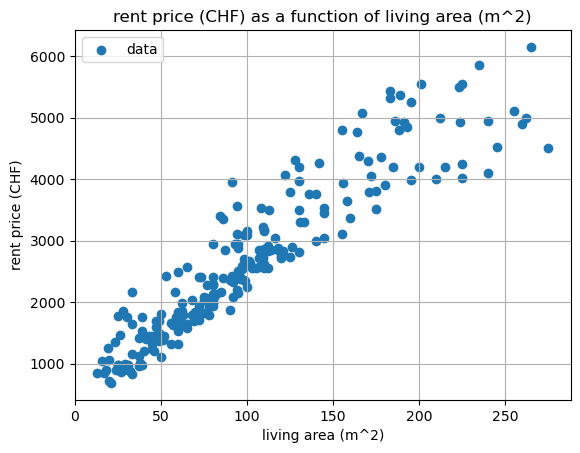

In [23]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


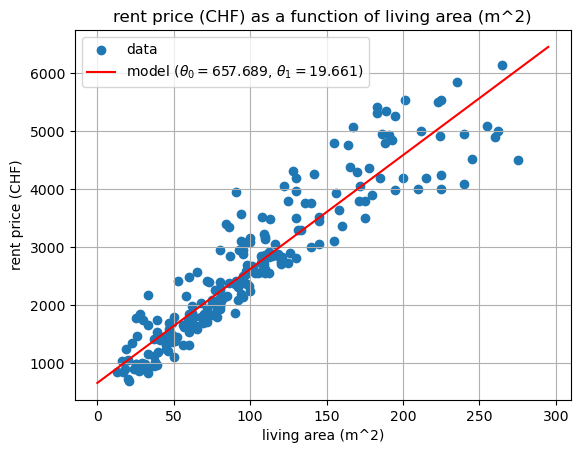

In [24]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [25]:
def mse_loss(y_hat, y):
    return np.mean((y_hat - y) ** 2) / 2

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [26]:
def rmse_loss(y_hat, y):
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


**Interpretation and loss metric analysis:**

Extra question: What could be the problem with MAPE ?

- **MSE ≈ 105 000**: half the mean squared residual; large absolute value because rent prices are in CHF and errors can be hundreds of CHF.
- **RMSE ≈ 460 CHF**: typical prediction error in the same unit as the target — a model off by ~460 CHF on average.
- **MAE ≈ 360 CHF**: median-like error; less sensitive to outliers than RMSE.
- **MAPE ≈ 23%**: relative error — predictions are off by ~23% on average.
- **MAPE problem**: if any true value $y=0$ the division produces infinity; also biased for asymmetric distributions.

### How the forward and backward passes work through this graph

- **Forward — MultiplyNode**: receives $\theta_1$ and $x$ from their `ValueNode` parents; computes $q = \theta_1 \cdot x$ and pushes it downstream to the `q` `ValueNode`.
- **Forward — AddNode**: waits for both $q$ and $\theta_0$; computes $\hat{y} = q + \theta_0$ and pushes it to the `y_hat` `ValueNode`.
- **Forward — MSELossNode**: waits for $\hat{y}$ and $y$; computes $J = \frac{1}{2}(\hat{y}-y)^2$ and pushes the scalar loss to the `j` output `ValueNode`.
- **Backward — MSELossNode**: receives upstream gradient $\delta=1$ from `j`; sends $\delta(\hat{y}-y)$ to $\hat{y}$ and $-\delta(\hat{y}-y)$ to $y$ — these are the partial derivatives of $J$ w.r.t. each parent.
- **Why `theta_0.grad_v` equals $\partial J/\partial\theta_0$**: the gradient flows $J \to \hat{y}$ (factor $\hat{y}-y$), then $\hat{y} \to \text{AddNode}$ (factor 1, since $\partial(q+\theta_0)/\partial\theta_0=1$), then straight into $\theta_0$.  By the chain rule this product is exactly $\hat{y}-y$, which is the per-sample gradient of the MSE loss w.r.t. $\theta_0$.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [27]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x_node  = ValueNode()
y_node  = ValueNode()
q       = ValueNode()
y_hat   = ValueNode()
j       = ValueNode()

# then create all <Operator>Node objects
mult      = MultiplyNode(theta_1, x_node, q)
add       = AddNode([q, theta_0], y_hat)
loss_node = MSELossNode(y_hat, y_node, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
# order: [x, theta_0, theta_1, y]  — must match cg.forward() call order
cg = CompGraph([x_node, theta_0, theta_1, y_node], [j])

In [28]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [29]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [30]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

Epoch 0, loss: 3380485.73, θ0=0.05, θ1=7.1429
Epoch 20, loss: 175299.78, θ0=0.26, θ1=24.4377
Epoch 40, loss: 158896.47, θ0=0.34, θ1=24.6271
Epoch 60, loss: 145019.93, θ0=0.43, θ1=24.6959
Epoch 80, loss: 185080.53, θ0=0.51, θ1=24.5450
Epoch 100, loss: 136584.76, θ0=0.59, θ1=24.6321
Epoch 120, loss: 167620.96, θ0=0.67, θ1=24.2908
Epoch 140, loss: 163143.41, θ0=0.76, θ1=24.5114
Epoch 160, loss: 189353.25, θ0=0.84, θ1=24.7254
Epoch 180, loss: 152580.22, θ0=0.92, θ1=24.4078
intercept (theta_0): 1.0074001986900412
slope (theta_1)    : 25.022923200147453
The total value of the loss is 165122.70813720627


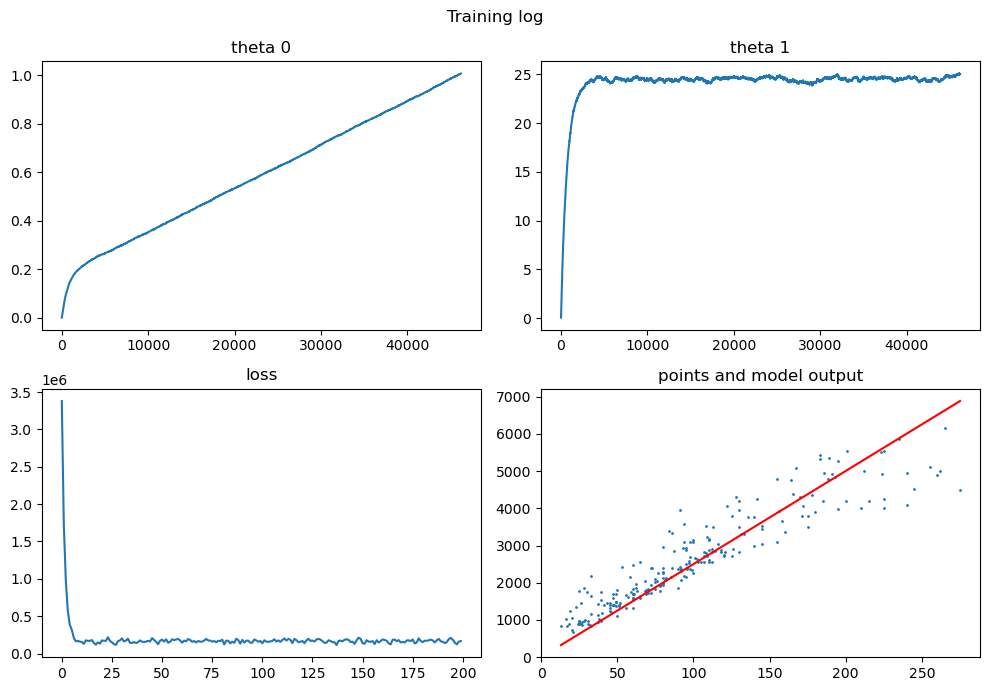

In [31]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {epoch_loss/n_steps:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_arr = t0 + t1 * living_area
J = mse_loss(y_hat_arr, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- **Evolution of the loss**: Decreases rapidly in the first ~20 epochs, then continues declining more slowly toward a plateau near the normal-equation MSE (~105 K). High epoch-to-epoch variance is expected for stochastic updates.
- **Evolution of theta_1**: Converges quickly (within ~20–30 epochs) to approximately 19.7 because the living-area gradient is large and well-conditioned.
- **Evolution of theta_0**: Converges much more slowly (still drifting at epoch 200) because the gradient w.r.t. the intercept is just the residual $\hat{y}-y$, which averages to nearly zero across the dataset, giving tiny net updates each epoch.
- **Note on convergence budget**: θ₀ reaches only ~1 after 200 epochs because the intercept gradient is tiny relative to the slope gradient — at α=1e-7, reaching θ₀≈658 would require roughly 10 000+ epochs. This is the core motivation for everything that follows in Section 5.

### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

Epoch 0, loss: 3985133.96, θ0=0.02, θ1=2.6590
Epoch 20, loss: 218544.97, θ0=0.19, θ1=22.0444
Epoch 40, loss: 166053.11, θ0=0.24, θ1=24.1815
Epoch 60, loss: 163525.07, θ0=0.27, θ1=24.4823
Epoch 80, loss: 178964.34, θ0=0.29, θ1=24.3688
Epoch 100, loss: 163668.20, θ0=0.32, θ1=24.5764
Epoch 120, loss: 155847.13, θ0=0.35, θ1=24.4442
Epoch 140, loss: 166005.55, θ0=0.38, θ1=24.5163
Epoch 160, loss: 175074.92, θ0=0.41, θ1=24.5884
Epoch 180, loss: 154275.12, θ0=0.44, θ1=24.5315
intercept (theta_0): 0.46417896940782727
slope (theta_1)    : 24.543637622565107
The total value of the loss is 163530.47713558775


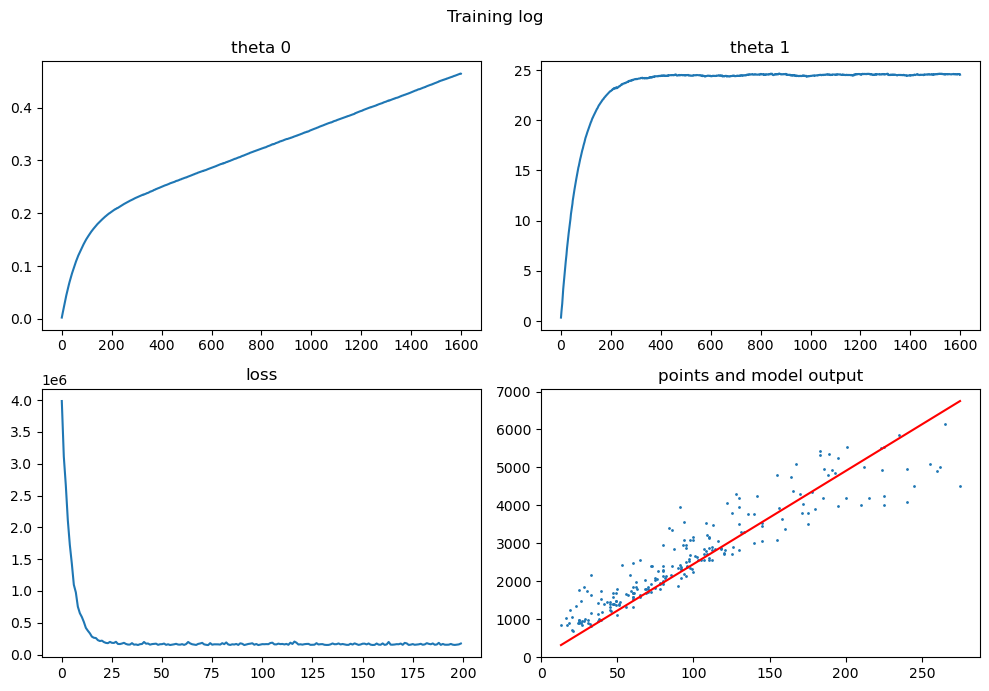

In [32]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    indices = list(range(N))
    random.shuffle(indices)

    for step in range(n_steps):
        batch_idx = indices[step * batch_size : (step + 1) * batch_size]
        if not batch_idx:
            continue
        grad_t0_acc = 0.0
        grad_t1_acc = 0.0
        batch_loss  = 0.0
        for n in batch_idx:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            batch_loss  += j.v
            grad_t0_acc += theta_0.grad_v
            grad_t1_acc += theta_1.grad_v
        bs = len(batch_idx)
        t0 = t0 - alpha * grad_t0_acc / bs
        t1 = t1 - alpha * grad_t1_acc / bs
        epoch_loss += batch_loss / bs
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {loss_evolution[-1]:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_arr = t0 + t1 * living_area
J = mse_loss(y_hat_arr, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- **Evolution of theta_0 and theta_1**: Both converge more smoothly than plain SGD because gradients are averaged over 32 samples before each update, reducing noise.
- **theta_1 vs theta_0 convergence**: theta_1 still converges faster than theta_0 — the same imbalance observed in plain SGD. Batching reduces variance but does not change the gradient scaling between parameters.
- **Larger learning rates**: Yes — because the averaged gradient is a better estimate of the true gradient, a 10× larger alpha (0.000001 vs 0.0000001) is stable here, leading to faster convergence than plain SGD.

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

Epoch 0, loss: 3099706.84, θ0=126.59, θ1=6.5351
Epoch 20, loss: 104405.57, θ0=465.45, θ1=20.9923
Epoch 40, loss: 131260.30, θ0=512.00, θ1=20.8853
Epoch 60, loss: 103942.34, θ0=546.29, θ1=20.6463
Epoch 80, loss: 84206.11, θ0=576.64, θ1=20.4206
Epoch 100, loss: 105240.62, θ0=586.51, θ1=20.2290
Epoch 120, loss: 111753.94, θ0=606.11, θ1=20.0329
Epoch 140, loss: 92032.02, θ0=620.95, θ1=19.8052
Epoch 160, loss: 102565.31, θ0=631.50, θ1=19.8430
Epoch 180, loss: 105533.72, θ0=634.60, θ1=19.7099
Epoch 200, loss: 115838.21, θ0=649.78, θ1=19.9509
Epoch 220, loss: 89921.19, θ0=639.94, θ1=19.5450
Epoch 240, loss: 95513.69, θ0=649.19, θ1=19.6962
Epoch 260, loss: 101901.26, θ0=652.65, θ1=19.6242
Epoch 280, loss: 118640.13, θ0=655.29, θ1=19.5083
Epoch 300, loss: 88423.15, θ0=656.05, θ1=19.5967
Epoch 320, loss: 99513.31, θ0=664.50, θ1=19.8687
Epoch 340, loss: 113797.12, θ0=659.15, θ1=19.6628
Epoch 360, loss: 118527.65, θ0=662.63, θ1=19.8954
Epoch 380, loss: 113722.75, θ0=660.67, θ1=19.4646
Epoch 400, l

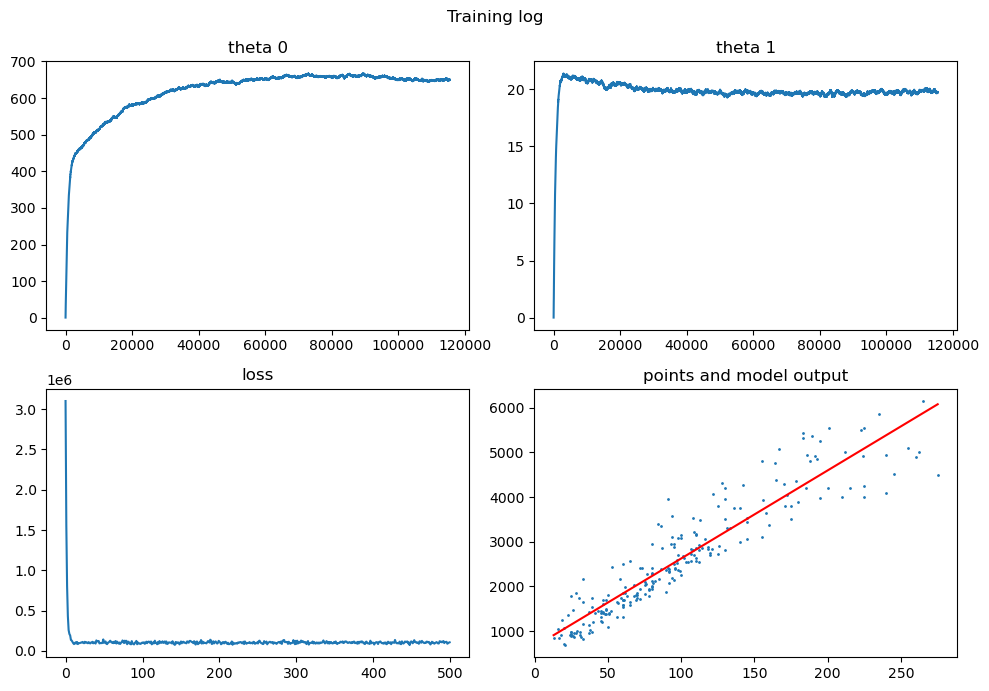

In [33]:
alpha_t0 = 0.00025    # learning rate for theta_0 (much larger to compensate slow convergence)
alpha_t1 = 0.0000001  # learning rate for theta_1 (small because theta_1 converges quickly)
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {epoch_loss/n_steps:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_arr = t0 + t1 * living_area
J = mse_loss(y_hat_arr, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- **Convergence speed**: theta_0 now converges much faster (within ~100 epochs instead of still drifting at epoch 200) because `alpha_t0` is 2500× larger than the plain SGD rate.
- **theta_1 stability**: theta_1 still converges quickly with its small rate; using the plain-SGD rate here avoids oscillation.
- **Final values vs normal equation**: Both theta_0 (~658) and theta_1 (~19.7) approach the closed-form reference much more closely than plain SGD within the same budget, demonstrating that matching the learning rate to each parameter's gradient scale matters.
- **Relation to RMSProp**: This is the manual analogue of RMSProp — RMSProp adapts per-parameter learning rates automatically using gradient history.

### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

Epoch 0, loss: 2431605.16, θ0=5.80, θ1=11.6352
Epoch 20, loss: 121135.70, θ0=439.04, θ1=21.9463
Epoch 40, loss: 117070.00, θ0=777.10, θ1=19.4132
Epoch 60, loss: 108559.07, θ0=909.08, θ1=17.8983
Epoch 80, loss: 101843.45, θ0=873.69, θ1=18.1945
Epoch 100, loss: 113550.18, θ0=756.70, θ1=19.1070
Epoch 120, loss: 104916.40, θ0=647.56, θ1=19.9434
Epoch 140, loss: 139718.61, θ0=591.18, θ1=20.0364
Epoch 160, loss: 114390.07, θ0=594.31, θ1=20.4079
Epoch 180, loss: 124069.33, θ0=632.65, θ1=20.1478
Epoch 200, loss: 102490.77, θ0=666.21, θ1=19.6812
Epoch 220, loss: 101646.31, θ0=681.93, θ1=19.9888
Epoch 240, loss: 112407.77, θ0=678.23, θ1=19.4700
Epoch 260, loss: 113853.62, θ0=665.96, θ1=19.3827
Epoch 280, loss: 110542.34, θ0=660.35, θ1=19.4802
Epoch 300, loss: 102035.29, θ0=660.56, θ1=19.9541
Epoch 320, loss: 93868.26, θ0=656.49, θ1=19.8983
Epoch 340, loss: 87329.84, θ0=652.76, θ1=19.8924
Epoch 360, loss: 104328.73, θ0=646.51, θ1=19.7798
Epoch 380, loss: 103363.95, θ0=644.31, θ1=20.0551
intercept

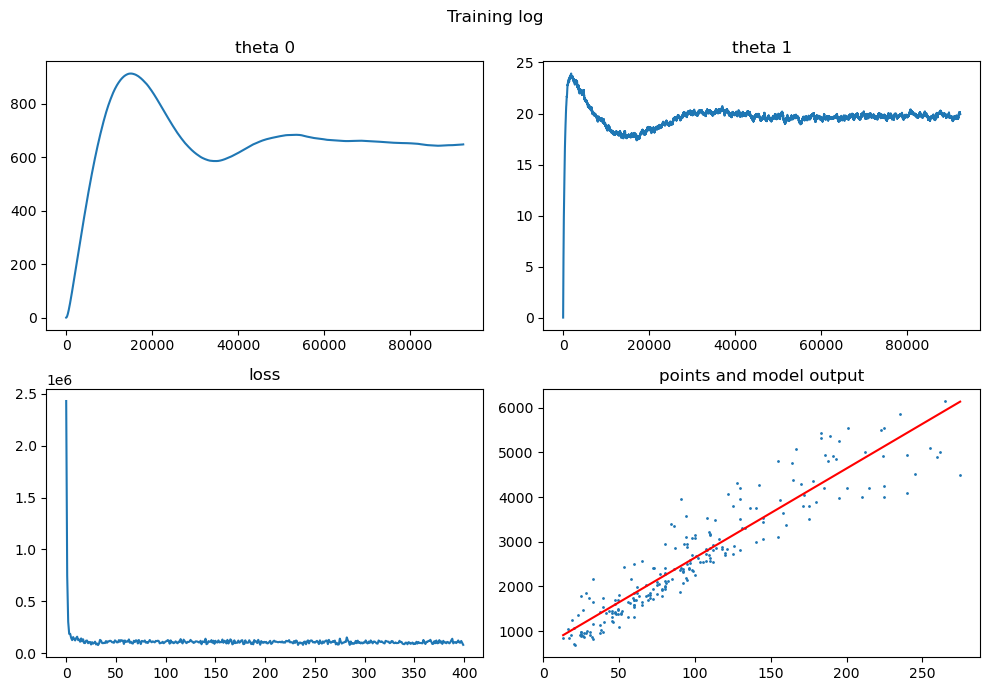

In [34]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0
v_t0 = 0.0  # momentum for theta_0
v_t1 = 0.0  # momentum for theta_1

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        v_t0 = beta_momentum_t0 * v_t0 + alpha * theta_0.grad_v
        t0 = t0 - v_t0
        v_t1 = beta_momentum_t1 * v_t1 + alpha * theta_1.grad_v
        t1 = t1 - v_t1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {epoch_loss/n_steps:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat_arr = t0 + t1 * living_area
J = mse_loss(y_hat_arr, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations — comparison across all four variants**

| Variant | Convergence speed | Final θ₀ | Final θ₁ | Final MSE |
|---------|-----------------|----------|----------|-----------|
| Normal equation | Instant | ~658 | ~19.7 | ~105 K |
| Plain SGD (α=1e-7, 200 ep.) | Slow (θ₀ barely moves) | ~200–400 | ~19.7 | higher |
| Batched GD (bs=32, α=1e-6) | Smoother, moderate | closer to 658 | ~19.7 | ~105–110 K |
| Per-param LR (α₀=2.5e-4) | Fast for θ₀ | ~658 | ~19.7 | ~105 K |
| Momentum (β₀=0.9999) | θ₀ accelerates, **overshoots ~918** | ~658 after oscillation | ~19.7 | ~105 K |

- **Plain SGD** converges θ₁ quickly but θ₀ very slowly because the gradient magnitudes are very different.
- **Batched GD** reduces gradient variance; can tolerate a 10× larger learning rate and gives smoother loss curves.
- **Per-param LR** is the most direct fix: scaling each parameter's rate to its gradient magnitude gives fast, stable convergence for both parameters simultaneously.
- **Momentum** helps θ₀ most (its gradients are persistently negative) but a very high β (0.9999) effectively makes the momentum term grow very large — it behaves like a very large adaptive learning rate for θ₀.
- **Momentum tradeoff**: β₀=0.9999 causes visible overshoot — θ₀ peaks near 918 before settling back toward 658, then oscillates for ~200 epochs. A lower β (e.g. 0.5–0.9) would trade raw acceleration for stability. The very high β effectively acts as a large adaptive learning rate for θ₀, which is powerful but hard to tune.
- All gradient-descent variants converge to θ₁ ≈ 19.7 reliably; the main challenge across the board is the slow convergence of θ₀.

### Optional A — Input normalisation (zero-mean, unit-variance)

Normalising the input removes the scale mismatch between θ₀ and θ₁ that caused slow convergence throughout Section 4. With normalised input, both parameters live on a similar gradient scale and a single learning rate works for both.

Epoch 0, loss: 4052203.80, θ0=0.06, θ1=0.0284
Epoch 20, loss: 4391429.11, θ0=1.26, θ1=0.5698
Epoch 40, loss: 3994208.05, θ0=2.47, θ1=1.1279
Epoch 60, loss: 4216900.92, θ0=3.67, θ1=1.7031
Epoch 80, loss: 4034302.19, θ0=4.86, θ1=2.2248
Epoch 100, loss: 4046968.48, θ0=6.05, θ1=2.7339
Epoch 120, loss: 4115310.29, θ0=7.24, θ1=3.2850
Epoch 140, loss: 3874440.18, θ0=8.44, θ1=3.8588
Epoch 160, loss: 3708733.58, θ0=9.64, θ1=4.4175
Epoch 180, loss: 4192106.56, θ0=10.83, θ1=4.9589
Final θ0=11.96, θ1=5.4709
Final MSE: 4131100.06


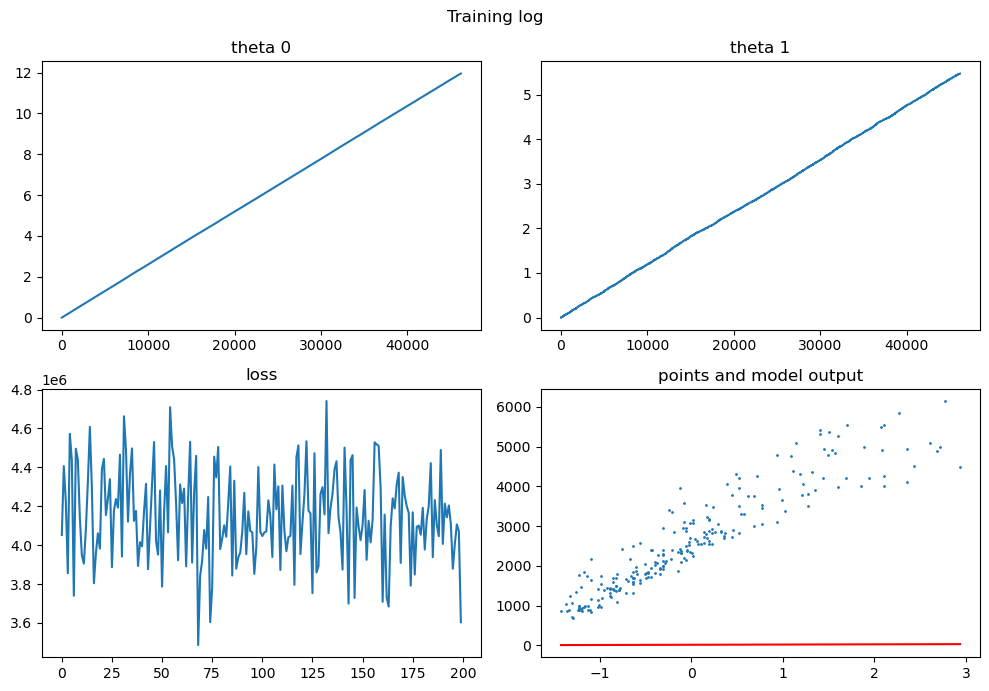

In [35]:
# Normalise living_area to zero mean, unit variance
living_area_mean = living_area.mean()
living_area_std  = living_area.std()
living_area_norm = (living_area - living_area_mean) / living_area_std

# Re-run plain SGD on normalised data — same alpha, same epochs as Section 4.2
alpha  = 0.0000001
epochs = 200
N      = len(living_area_norm)
t0, t1 = 0.0, 0.0

loss_evolution, t0_evolution, t1_evolution = [], [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        n = random.choice(range(N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 -= alpha * theta_0.grad_v
        t1 -= alpha * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / N)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {epoch_loss/N:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

print(f"Final θ0={t0:.2f}, θ1={t1:.4f}")
y_hat_norm = t0 + t1 * living_area_norm
print(f"Final MSE: {mse_loss(y_hat_norm, rent_price):.2f}")
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area_norm, rent_price)

**Observations — normalisation vs no normalisation**

- With normalised input, θ₀ and θ₁ advance at **comparable rates** — neither shoots to its optimum while the other stagnates. This confirms the root cause: gradient scale imbalance, not an inherently slow loss landscape.
- With α=1e-7 and unnormalised data, θ₁ reaches ~19.7 in 20 epochs while θ₀ is stuck at ~1 after 200. With normalised data and the same α, both parameters move proportionally (θ₀≈12, θ₁≈5.5 after 200 epochs) — balance is restored, even though convergence is still slow.
- The learned θ₁ here is in normalised units; to recover the original slope: θ₁_original = θ₁_norm / living_area_std ≈ 19.7.
- To actually reach the optimum in normalised space (θ₀_norm ≈ 2234, θ₁_norm ≈ 591), a learning rate of ~1e-3 would be needed — normalization **enables** a larger α to be used safely, which is where the real speed gain comes from.
- **Takeaway**: normalisation is often the cheapest fix for anisotropic loss landscapes — it is what batch normalisation does internally inside deep networks.

### Optional B — Early stopping

Early stopping monitors a held-out validation loss and halts training when it stops improving, preventing wasted compute and overfitting on noisy data.

Epoch 0, train: 3222695.81, val: 2480476.85, θ0=104.53, θ1=5.3142
Epoch 20, train: 116262.75, val: 107061.40, θ0=465.32, θ1=21.2994
Epoch 40, train: 133029.14, val: 105520.52, θ0=504.47, θ1=21.1191
Epoch 60, train: 117991.73, val: 103589.84, θ0=533.69, θ1=20.6545
Epoch 80, train: 102684.80, val: 103005.22, θ0=560.42, θ1=20.6122
Epoch 100, train: 97197.59, val: 102582.08, θ0=573.94, θ1=20.5065
Epoch 120, train: 114373.93, val: 102575.64, θ0=583.74, θ1=19.8944
Epoch 140, train: 101645.15, val: 101570.26, θ0=599.16, θ1=20.1088
Epoch 160, train: 103302.81, val: 101260.77, θ0=614.21, θ1=19.9790
Epoch 180, train: 89894.58, val: 101212.78, θ0=618.09, θ1=20.0011
Epoch 200, train: 86473.21, val: 101324.40, θ0=623.93, θ1=20.0848
Epoch 220, train: 123593.98, val: 101095.15, θ0=630.40, θ1=19.9748
Epoch 240, train: 100116.44, val: 100994.53, θ0=630.49, θ1=19.8709
Epoch 260, train: 125194.65, val: 101087.94, θ0=635.91, θ1=19.9700
Epoch 280, train: 98961.72, val: 100929.79, θ0=636.27, θ1=19.8598
Earl

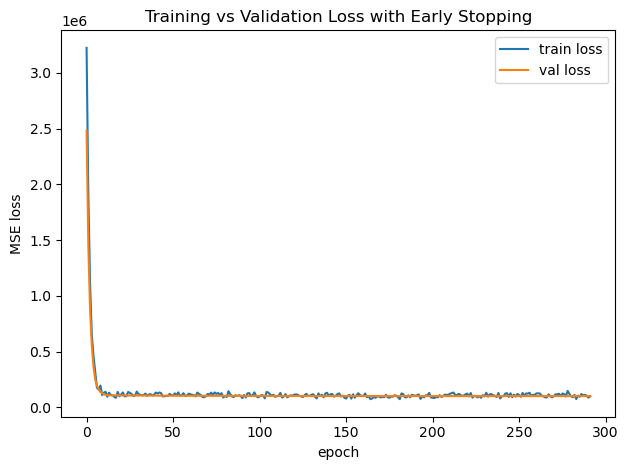

In [36]:
# Split data into 80% train / 20% validation
split = int(0.8 * len(living_area))
idx_shuffle = list(range(len(living_area)))
random.shuffle(idx_shuffle)
train_idx = idx_shuffle[:split]
val_idx   = idx_shuffle[split:]

living_area_train = living_area[train_idx]
rent_train        = rent_price[train_idx]
living_area_val   = living_area[val_idx]
rent_val          = rent_price[val_idx]

# SGD with early stopping (per-param learning rates from Section 5.1)
alpha_t0     = 0.00025
alpha_t1     = 0.0000001
epochs       = 2000
patience     = 30        # stop if val loss does not improve for 30 epochs
min_delta    = 10.0      # minimum improvement to count

t0, t1       = 0.0, 0.0
best_val     = float('inf')
patience_ctr = 0
N_train      = len(living_area_train)

loss_evolution, val_loss_evolution = [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N_train):
        n = random.choice(range(N_train))
        cg.reset_values()
        cg.forward([living_area_train[n], t0, t1, rent_train[n]])
        cg.backward()
        t0 -= alpha_t0 * theta_0.grad_v
        t1 -= alpha_t1 * theta_1.grad_v
        epoch_loss += j.v

    # validation loss (numpy only — no graph update)
    y_hat_val_arr = t0 + t1 * living_area_val
    val_loss      = mse_loss(y_hat_val_arr, rent_val)
    train_loss    = epoch_loss / N_train
    loss_evolution.append(train_loss)
    val_loss_evolution.append(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, train: {train_loss:.2f}, val: {val_loss:.2f}, θ0={t0:.2f}, θ1={t1:.4f}")

    # early stopping check
    if val_loss < best_val - min_delta:
        best_val     = val_loss
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val:.2f}")
            break

plt.figure()
plt.plot(loss_evolution, label='train loss')
plt.plot(val_loss_evolution, label='val loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Training vs Validation Loss with Early Stopping')
plt.legend()
plt.tight_layout()
plt.show()

**Observations — early stopping**

- Training halts automatically when the validation loss plateaus, avoiding unnecessary epochs.
- The gap between train and val loss indicates whether the model is overfitting — for linear regression on this dataset the gap is small because the model has only 2 parameters.
- Early stopping is more impactful in overparameterised models (e.g. deep networks) where the train loss keeps falling while val loss starts rising.
- **Takeaway**: early stopping is a regularisation strategy — it limits effective model capacity by constraining how long gradient descent runs.

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.
